# Project 1 - Regression
### Predict total bikes that will be rented per day
#### Group V
+ Ana Isabel Moura, 20250168
+ Ayoub Mask, 2025XXX
+ Beatriz Lobão, 
+ Joao Bernardino, 
+ Lara Pereira

Version 2 - 01/04/2026



## Business Understanding

#### Business: 
+ Bicycle rentals 

#### Goals: 
 + Predict next day total rentals at 15.00H. 
 + Assist Marketing team with the social media budget. 
 + Assist the team with resources and people allocation for next day. 


#### Success Criteria:
- R² (test set) | ≥ 0.75 
- MAPE (test set) | ≤ 20% 
- Generalisation gap | Train R² – Test R² < 0.10

#### Modelling Approach
+ Linear Regression
+ Decision Tree
+ Neural Networks

## Data Undertanding 

In [1]:
# Loading packages
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler


In [2]:
# Loading the dataset and visualizing summary statistics
ds = pd.read_excel('/Users/anamoura/Desktop/MachineLearning/Project_01/bike_day_v2.xlsx', engine='openpyxl')
ds.describe(include='all').T

,count,mean,min,25%,50%,75%,max,std
instant,732.0,366.352459,1.0,183.75,366.5,549.25,731.0,211.236679
dteday,732,2012-01-01 08:27:32.459016448,2011-01-01 00:00:00,2011-07-02 18:00:00,2012-01-01 12:00:00,2012-07-02 06:00:00,2012-12-31 00:00:00,NaN
season,732.0,2.497268,1.0,2.0,3.0,3.0,4.0,1.110203
yr,732.0,0.501366,0.0,0.0,1.0,1.0,1.0,0.50034
mnth,732.0,6.523224,1.0,4.0,7.0,10.0,12.0,3.450769
holiday,732.0,0.028689,0.0,0.0,0.0,0.0,1.0,0.167044
weekday,730.0,3.00274,0.0,1.0,3.0,5.0,6.0,2.004793
workingday,732.0,0.68306,0.0,0.0,1.0,1.0,1.0,0.465602
schoolday,454.0,0.460352,0.0,0.0,0.0,1.0,1.0,0.498975
weathersit,732.0,1.394809,1.0,1.0,1.0,2.0,3.0,0.544718


In [3]:
#Show top rows
ds.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,schoolday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6.0,0,0.0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0.0,0,0.0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1.0,1,1.0,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2.0,1,1.0,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3.0,1,1.0,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:
#Check for data types in all dataset
print(ds.dtypes)

instant                int64
dteday        datetime64[ns]
season                 int64
yr                     int64
mnth                   int64
holiday                int64
weekday              float64
workingday             int64
schoolday            float64
weathersit             int64
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
casual                 int64
registered             int64
cnt                    int64
dtype: object


#### Data Quality

In [5]:
# Check for missing values and data types 
print(ds.isnull().sum())


instant         0
dteday          0
season          0
yr              0
mnth            0
holiday         0
weekday         2
workingday      0
schoolday     278
weathersit      0
temp            0
atemp           0
hum             0
windspeed       0
casual          0
registered      0
cnt             0
dtype: int64


In [6]:
# Quantitative check on missing values
print("Percentage of missing data per column:")
print((ds.isnull().sum() / len(ds)) * 100)

Percentage of missing data per column:
instant        0.000000
dteday         0.000000
season         0.000000
yr             0.000000
mnth           0.000000
holiday        0.000000
weekday        0.273224
workingday     0.000000
schoolday     37.978142
weathersit     0.000000
temp           0.000000
atemp          0.000000
hum            0.000000
windspeed      0.000000
casual         0.000000
registered     0.000000
cnt            0.000000
dtype: float64


Observation: 
In the Data Understanding phase, we identified significant gaps in two specific features: `weekday`(0,27%) and `schoolday`(37,97%).

In [7]:
# Integrity check: cnt must always equal casual + registered
integrity_errors = (ds['cnt'] != (ds['casual'] + ds['registered'])).sum()
print(f'Integrity errors (cnt ≠ casual + registered): {integrity_errors}')

Integrity errors (cnt ≠ casual + registered): 0


#### Correlation Matrix

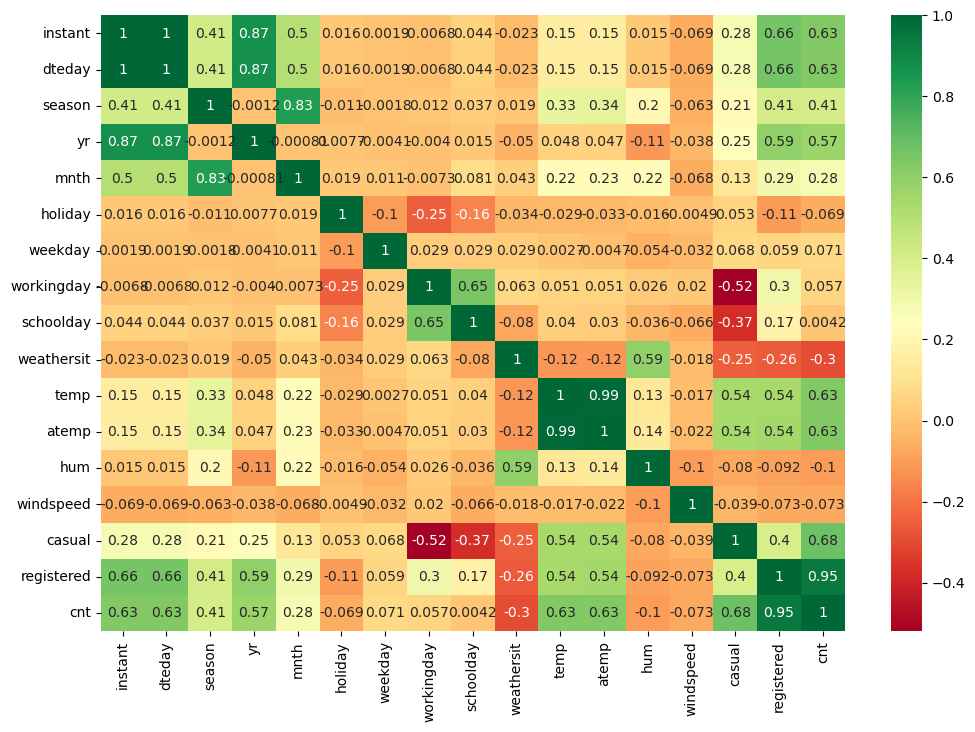

In [8]:
# Correlation matrix to find strong relationships with the target 'cnt'
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(ds.corr(), annot=True, cmap='RdYlGn')
plt.show()


#### Outliers

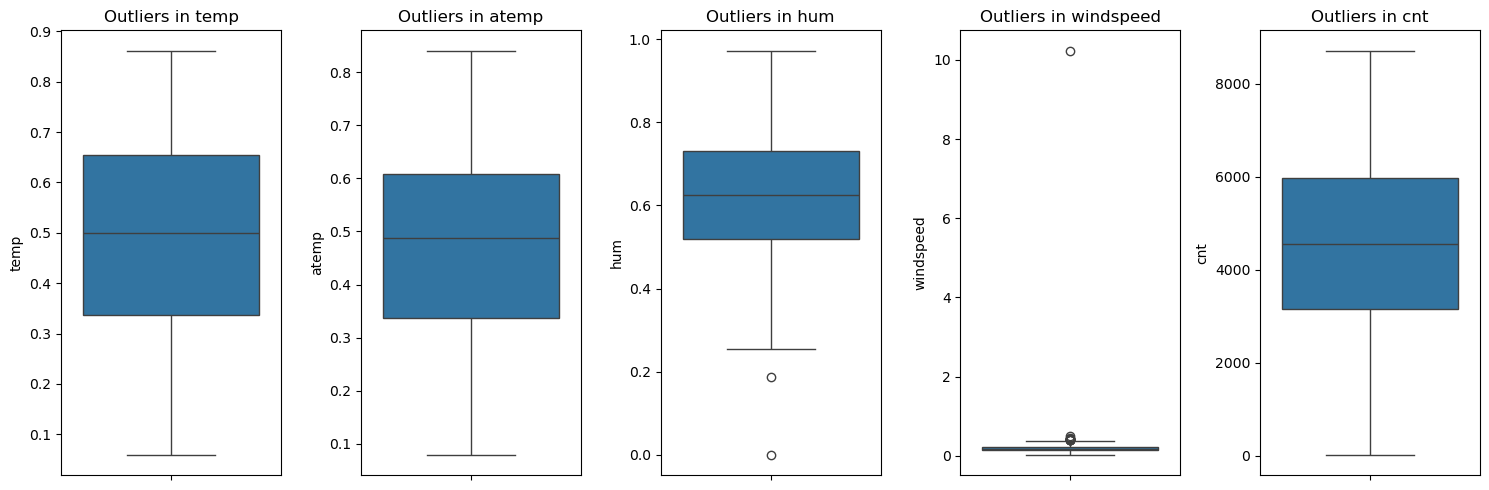

In [9]:
# Check for outliers in weather variables 
weather_cols = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']
plt.figure(figsize=(15, 5))
for i, col in enumerate(weather_cols):
    plt.subplot(1, 5, i+1)
    sns.boxplot(y=ds[col])
    plt.title(f'Outliers in {col}')
plt.tight_layout()

Obserations on outliers: 
1. The windspeed: The max value for windspeed is 10.234234.
 - Why it's strange: According to the dataset description, windspeed is normalized. Therefore, every value should strictly be between 0 and 1. A value of 10.23 is a physical impossibility in this context and will heavily skew the regression model.

2. The humidity: Min values of 0 and max of 0.9725. 
This value is normalizer from 0 to 1, but is it possible to have a 0 in humidity? 

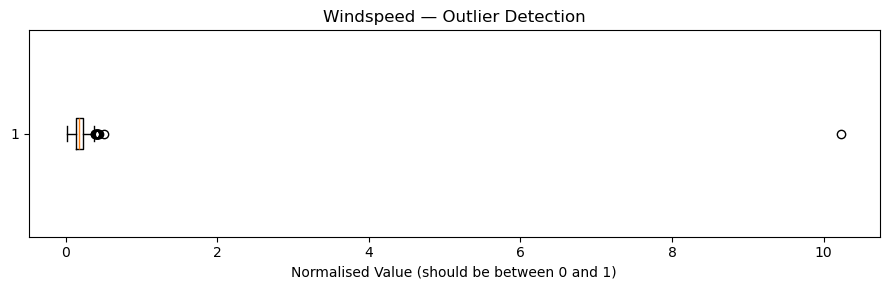

Max windspeed: 10.234234


In [10]:
# Windspeed outlier — max should be ≤ 1.0 (normalised)
fig, ax = plt.subplots(figsize=(9, 3))
ax.boxplot(ds['windspeed'], vert=False)
ax.set_title('Windspeed — Outlier Detection')
ax.set_xlabel('Normalised Value (should be between 0 and 1)')
plt.tight_layout()
plt.show()
print(f'Max windspeed: {ds["windspeed"].max()}')

In [11]:
#Check for the minimum humidity value
print(f"Minimum humidity recorded: {ds['hum'].min()}")

#Check for the maximum humidity value
print(f"Maximum humidity recorded: {ds['hum'].max()}")

# Count how many times 0 occurs
zero_hum_count = len(ds[ds['hum'] == 0])
print(f"Number of days with 0% humidity: {zero_hum_count}")

#Count how may times 1 occurs
one_hum_count = len(ds[ds['hum'] == 1])
print(f"Number of days with 100% humidity:{one_hum_count}")

Minimum humidity recorded: 0.0
Maximum humidity recorded: 0.9725
Number of days with 0% humidity: 1
Number of days with 100% humidity:0


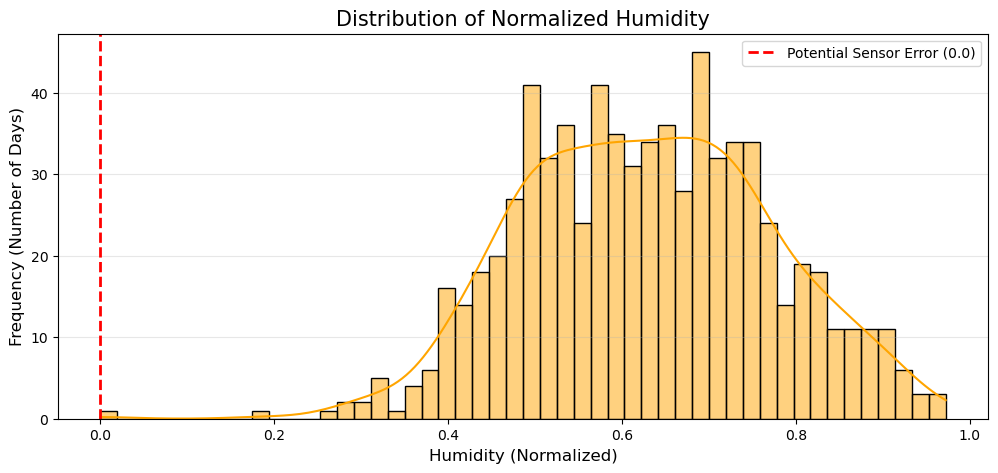

In [12]:
# See how many days have that 0.0 humidity
plt.figure(figsize=(12, 5))
sns.histplot(ds['hum'], bins=50, kde=True, color='orange')

# Adding a red line to highlight where the 0.0 values sit
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Potential Sensor Error (0.0)')

plt.title('Distribution of Normalized Humidity', fontsize=15)
plt.xlabel('Humidity (Normalized)', fontsize=12)
plt.ylabel('Frequency (Number of Days)', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


In [13]:
#Check the correlation between temp and atemp
correlation = ds[['temp', 'atemp']].corr()
print(f"Correlation between Temp and Atemp: \n{correlation}")

Correlation between Temp and Atemp: 
           temp     atemp
temp   1.000000  0.991703
atemp  0.991703  1.000000


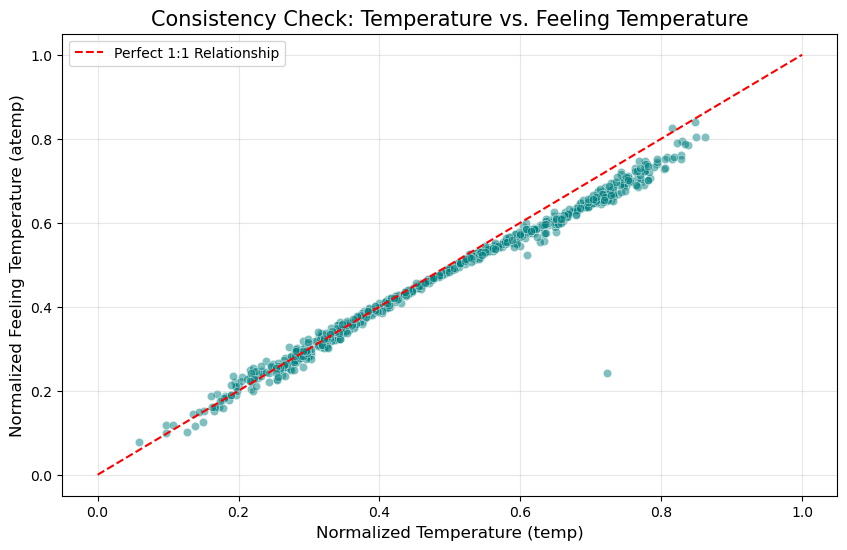

Correlation temp vs atemp: 0.9917


In [14]:
# Check if temp and atemp follow a logical linear relationship
plt.figure(figsize=(10, 6))
sns.scatterplot(data=ds, x='temp', y='atemp', alpha=0.5, color='teal')

# Adding a diagonal line for reference (where temp = atemp)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Perfect 1:1 Relationship')

plt.title('Consistency Check: Temperature vs. Feeling Temperature', fontsize=15)
plt.xlabel('Normalized Temperature (temp)', fontsize=12)
plt.ylabel('Normalized Feeling Temperature (atemp)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print(f'Correlation temp vs atemp: {ds["temp"].corr(ds["atemp"]):.4f}')

Observations: 
+ Should we do the modeling with temp or atemp variable? 
+ Is there any difference in rentals according to the temp or atemp info? 

+ `temp` and `atemp` have a correlation of ~0.99. Keeping both would cause multicollinearity in Linear Regression. We will drop `atemp`. The windspeed outlier (10.23) and humidity zero value will be corrected in Data Preparation.

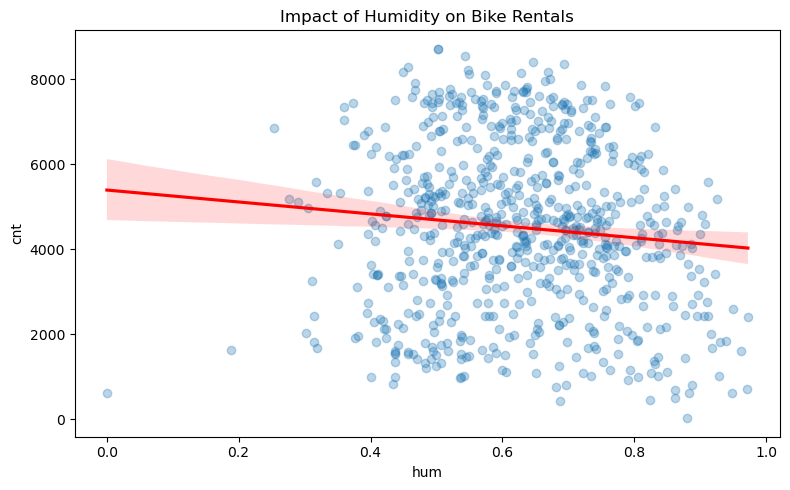

In [15]:
# Impact of humidity on bike rentals
plt.figure(figsize=(8, 5))
sns.regplot(data=ds, x='hum', y='cnt', scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
plt.title('Impact of Humidity on Bike Rentals')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Distribution of Total Rentals')

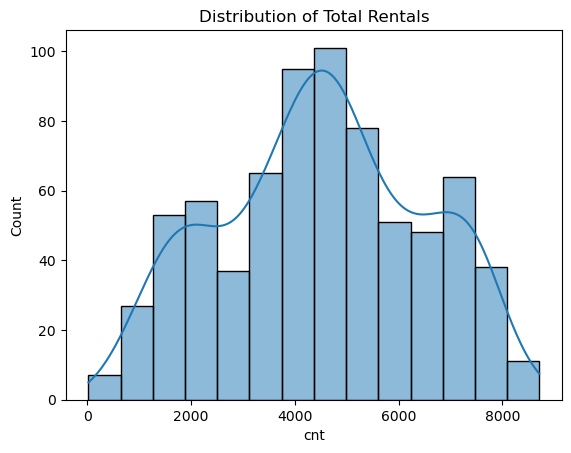

In [16]:
# Check for skewness in the variable 'cnt'
sns.histplot(ds['cnt'], kde=True)
plt.title('Distribution of Total Rentals')

Text(0.5, 1.0, 'Average Rentals: 2011 (0) vs 2012 (1)')

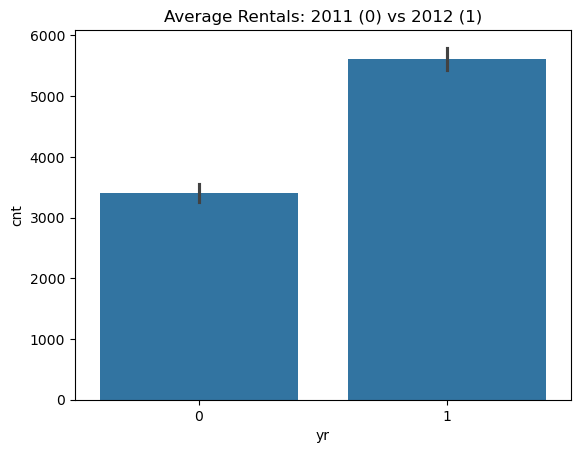

In [17]:
# Check if rentals increased from 2011 to 2012
sns.barplot(x='yr', y='cnt', data=ds)
plt.title('Average Rentals: 2011 (0) vs 2012 (1)')

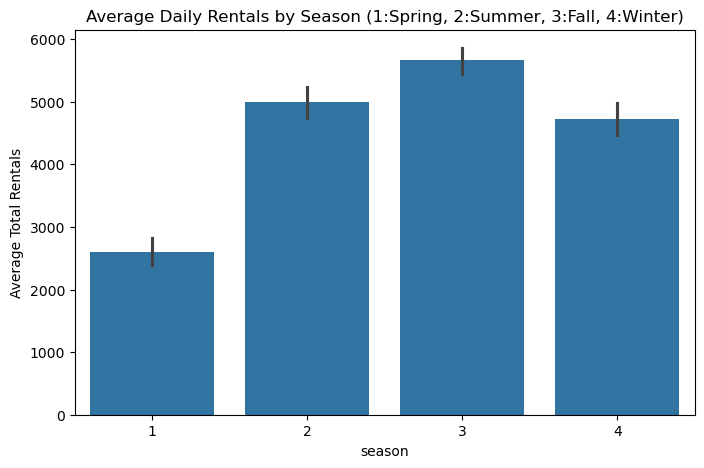

In [18]:
# Average rentals per season
plt.figure(figsize=(8, 5))
sns.barplot(x='season', y='cnt', data=ds)
plt.title('Average Daily Rentals by Season (1:Spring, 2:Summer, 3:Fall, 4:Winter)')
plt.ylabel('Average Total Rentals')
plt.show()

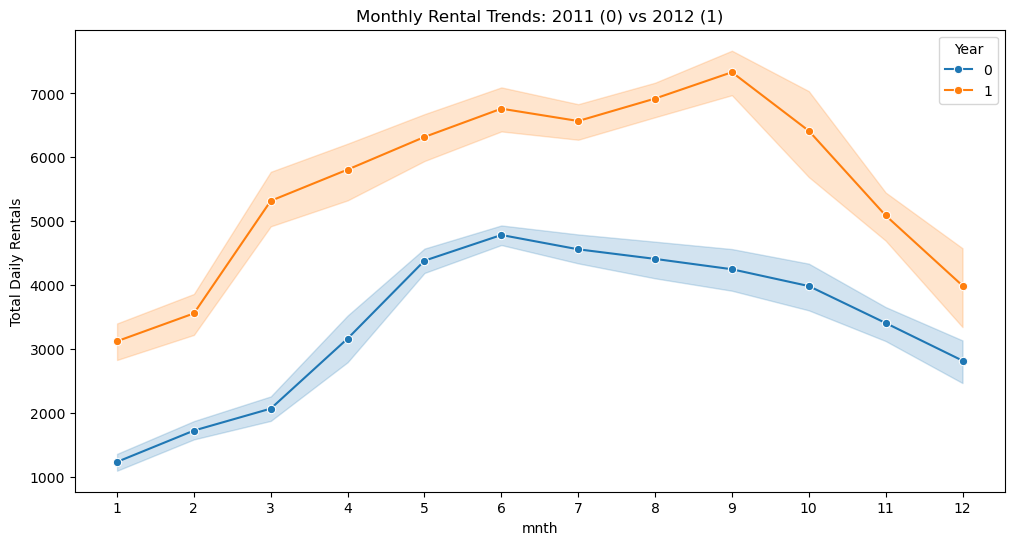

In [19]:
#Monthly trend across both years
plt.figure(figsize=(12, 6))
sns.lineplot(x='mnth', y='cnt', hue='yr', data=ds, marker='o')
plt.title('Monthly Rental Trends: 2011 (0) vs 2012 (1)')
plt.xticks(range(1, 13))
plt.ylabel('Total Daily Rentals')
plt.legend(title='Year')
plt.show()

Observations: 
+ In 2012, there was a peak in September. 
+ In 2011 the peak is in June. 

In [20]:
# Filter data for June (6) 2011 (0)
june_2011 = ds[(ds['mnth'] == 6) & (ds['yr'] == 0)]

# Check if there are any holidays in this month
holidays_in_june = june_2011[june_2011['holiday'] == 1]

print(f"Number of holidays in June 2011: {len(june_2011)}")
print(june_2011[['dteday', 'holiday', 'cnt']])

# Compare average rentals: Holiday vs. Non-Holiday in June 2011
print("\nAverage rentals in Sept 2012:")
print(june_2011.groupby('holiday')['cnt'].mean())

Number of holidays in June 2011: 30
        dteday  holiday   cnt
151 2011-06-01        0  3974
152 2011-06-02        0  4968
153 2011-06-03        0  5312
154 2011-06-04        0  5342
155 2011-06-05        0  4906
156 2011-06-06        0  4548
157 2011-06-07        0  4833
158 2011-06-08        0  4401
159 2011-06-09        0  3915
160 2011-06-10        0  4586
161 2011-06-11        0  4966
162 2011-06-12        0  4460
163 2011-06-13        0  5020
164 2011-06-14        0  4891
165 2011-06-15        0  5180
166 2011-06-16        0  3767
167 2011-06-17        0  4844
168 2011-06-18        0  5119
169 2011-06-19        0  4744
170 2011-06-20        0  4010
171 2011-06-21        0  4835
172 2011-06-22        0  4507
173 2011-06-23        0  4790
174 2011-06-24        0  4991
175 2011-06-25        0  5202
176 2011-06-26        0  5305
177 2011-06-27        0  4708
178 2011-06-28        0  4648
179 2011-06-29        0  5225
180 2011-06-30        0  5515

Average rentals in Sept 2012:
hol

In [21]:
# Filter data for September (9) 2012 (1)
sept_2012 = ds[(ds['mnth'] == 9) & (ds['yr'] == 1)]

# Check if there are any holidays in this month
holidays_in_sept = sept_2012[sept_2012['holiday'] == 1]

print(f"Number of holidays in September 2012: {len(holidays_in_sept)}")
print(holidays_in_sept[['dteday', 'holiday', 'cnt']])

# Compare average rentals: Holiday vs. Non-Holiday in September 2012
print("\nAverage rentals in Sept 2012:")
print(sept_2012.groupby('holiday')['cnt'].mean())

Number of holidays in September 2012: 1
        dteday  holiday   cnt
611 2012-09-03        1  6034

Average rentals in Sept 2012:
holiday
0    7375.1
1    6034.0
Name: cnt, dtype: float64


/var/folders/nl/gmgb358n27x2frmnd449xns80000gn/T/ipykernel_2310/48933296.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=june_data, x='yr', y='cnt', palette='viridis')


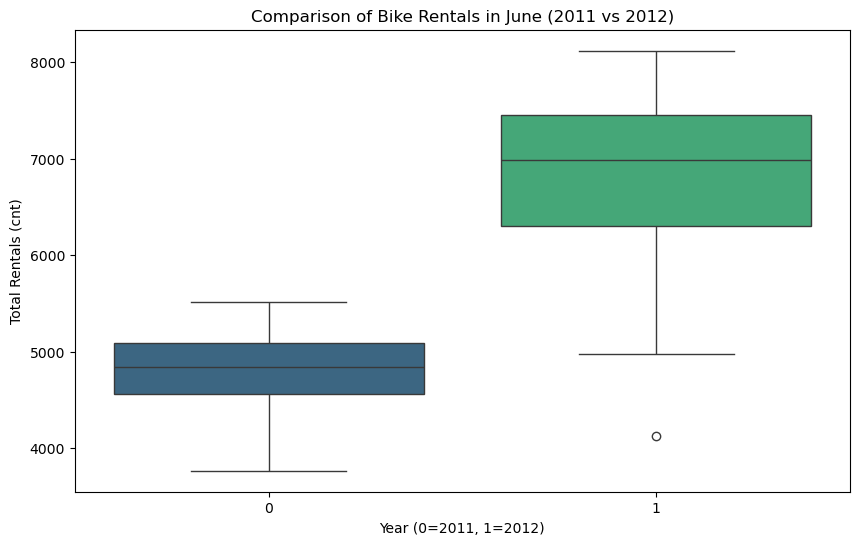

In [22]:
# Filter for June 
june_data = ds[ds['mnth'] == 6]

# Compare June 2011 vs June 2012
plt.figure(figsize=(10, 6))
sns.boxplot(data=june_data, x='yr', y='cnt', palette='viridis')
plt.title('Comparison of Bike Rentals in June (2011 vs 2012)')
plt.xlabel('Year (0=2011, 1=2012)')
plt.ylabel('Total Rentals (cnt)')
plt.show()

/var/folders/nl/gmgb358n27x2frmnd449xns80000gn/T/ipykernel_2310/1403591261.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sept_data, x='yr', y='cnt', palette='viridis')


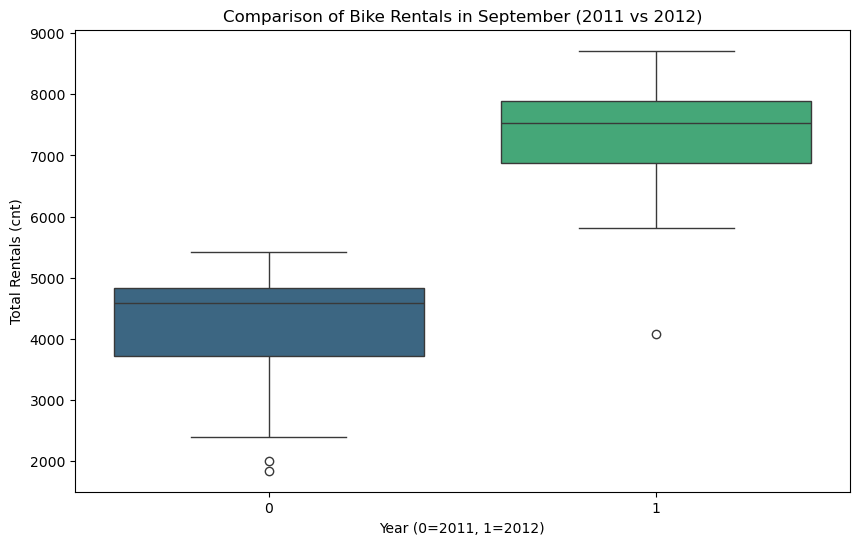

In [23]:
# Filter for september - Compare fi the trend keeps
sept_data = ds[ds['mnth'] == 9]

# Compare September 2011 vs September 2012
plt.figure(figsize=(10, 6))
sns.boxplot(data=sept_data, x='yr', y='cnt', palette='viridis')
plt.title('Comparison of Bike Rentals in September (2011 vs 2012)')
plt.xlabel('Year (0=2011, 1=2012)')
plt.ylabel('Total Rentals (cnt)')
plt.show()

Observations: 
In june of 2012 the bike rentals increaded. The trend is confirmed in September too. 

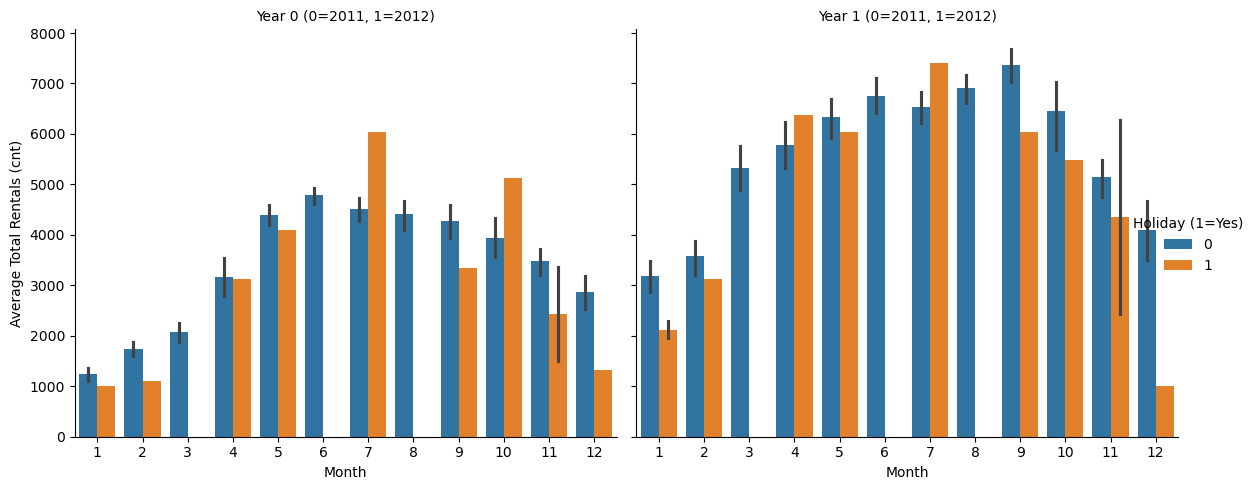

In [24]:
# Visualizing the impact of holidays across all months and years
# yr=0 is 2011, yr=1 is 2012
g = sns.catplot(
    data=ds, 
    x='mnth', 
    y='cnt', 
    hue='holiday', 
    col='yr', 
    kind='bar', 
    height=5, 
    aspect=1.2
)

g.set_axis_labels("Month", "Average Total Rentals (cnt)")
g.set_titles("Year {col_name} (0=2011, 1=2012)")
g._legend.set_title("Holiday (1=Yes)")
plt.show()

### Primary Conclusions
+ Seasonality interfers with the sales
+ Holidays don't have a direct correlation with the increase or decrease of rentals 

+ Strong seasonality, with a peak in 2012 in september
+ Variables causal and registered must be removed because it is only categoriezed afther the day ends. Do not interfer with the 15h pretiction. 


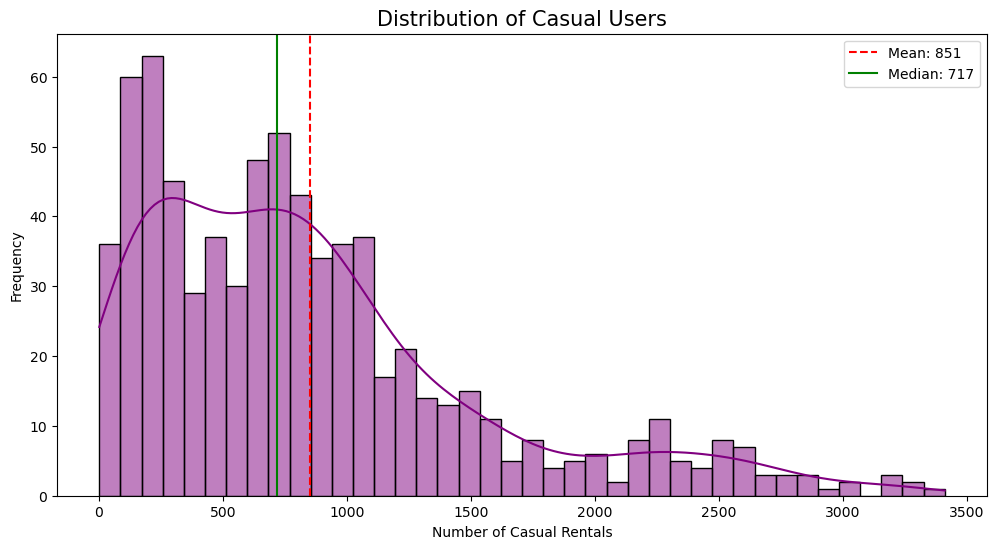

Skewness coefficient for Casual: 1.28


In [25]:
#Check casual Users
plt.figure(figsize=(12, 6))

# Histogram with a Kernel Density Estimate (KDE)
sns.histplot(ds['casual'], kde=True, color='purple', bins=40)

# Add lines for Mean and Median to see the gap
plt.axvline(ds['casual'].mean(), color='red', linestyle='--', label=f"Mean: {ds['casual'].mean():.0f}")
plt.axvline(ds['casual'].median(), color='green', linestyle='-', label=f"Median: {ds['casual'].median():.0f}")

plt.title('Distribution of Casual Users', fontsize=15)
plt.xlabel('Number of Casual Rentals')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Calculate the actual skewness coefficient
print(f"Skewness coefficient for Casual: {ds['casual'].skew():.2f}")

Observations: 
Casual colmn is right-skewed.

Upon analyzing the distribution of the casual variable, a significant positive (right) skew was identified (Mean: 851 vs. Median: 717). This indicates that while typical daily demand remains relatively stable around the median, the data is influenced by periodic "high-demand" outliers—likely corresponding to weekends, holidays, or favorable weather events. From a modeling perspective, this asymmetry suggests that a standard linear approach might over-estimate "normal" days or struggle with variance. We may need to consider data transformations (such as Log or Square Root) during the Data Preparation phase to normalize this feature and improve predictive stability.

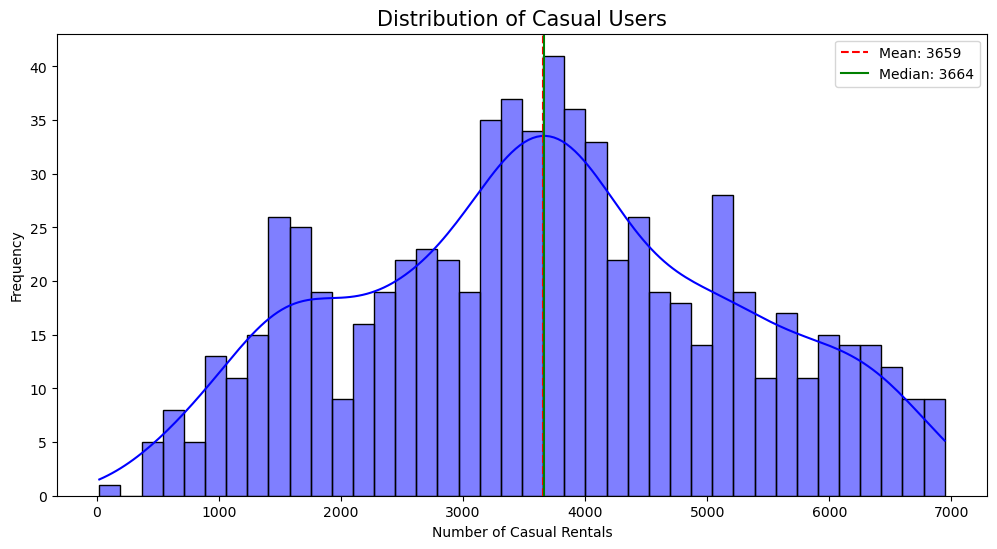

Skewness coefficient for Casual: 1.28


In [26]:
#Check registered Users
plt.figure(figsize=(12, 6))

# Histogram with a Kernel Density Estimate (KDE)
sns.histplot(ds['registered'], kde=True, color='blue', bins=40)

# Add lines for Mean and Median to see the gap
plt.axvline(ds['registered'].mean(), color='red', linestyle='--', label=f"Mean: {ds['registered'].mean():.0f}")
plt.axvline(ds['registered'].median(), color='green', linestyle='-', label=f"Median: {ds['registered'].median():.0f}")

plt.title('Distribution of Casual Users', fontsize=15)
plt.xlabel('Number of Casual Rentals')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Calculate the actual skewness coefficient
print(f"Skewness coefficient for Casual: {ds['casual'].skew():.2f}")

### Data Preparation, Modeling, Evaluation and Deployment 
for each Regression Model are in these files: 
+ Linear Regression: 02_GroupV_LinearRegression.ipynb 
+ Decisiom Trees: 03_GroupV_DecisionTrees.ipynb
+ Neural Networks: 04_GroupV_NeuralNetworks.ipynb


## Final Conclusions: 

### Model Comparison and Best Model Selection

Three models were implemented: **Linear Regression**, **Decision Tree**, and a **Neural Network (MLP Regressor)**, each with different levels of complexity and ability to capture patterns in the data.

The **Linear Regression** model served as a baseline. While it provided reasonable results, its performance was limited due to its inability to capture non-linear relationships present in the dataset.

The **Decision Tree** model improved upon this by capturing non-linear patterns and interactions between variables. However, it showed some instability and potential overfitting, which affected its generalization performance.

The **Neural Network** (MLP Regressor) achieved the best results among the three models. It obtained the highest R2 and the lowest error metrics, indicating superior predictive accuracy. Its ability to model complex, non-linear relationships allowed it to better fit the data while still maintaining good generalization, as seen by the similar performance on training and test sets.

Therefore, the **Neural Network was the best-performing model**, providing the most accurate and reliable predictions for this problem.